In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
temp = np.array([240.6, 280.1, 262.5, 182.7, 193.5, 276.7, 150.8, 269.1, 265.6, 217.9, 193.9, 190.4, 187.0, 214.5, 223.2, 230.3, 294.3, 264.9, 240.2, 293.4, 181.2, 173.2, 238.8, 156.4, 155.2, 224.7, 217.6, 283.0, 241.2, 224.5, 222.0, 185.9, 151.7, 177.9, 250.3, 179.1, 203.6, 150.5, 270.4, 172.4, 188.8, 277.6, 223.9, 272.8, 242.8, 257.6, 163.3, 228.5, 223.6, 276.3, 202.4, 236.7, 158.6, 206.2, 196.8, 171.8, 268.4, 205.0, 291.9, 235.5, 237.7, 242.5, 248.1, 171.9, 213.8, 184.7, 208.4, 164.0, 290.3, 181.2, 247.4, 193.6, 276.7, 246.0, 169.1, 272.5, 287.0, 281.1, 232.6, 171.1, 177.9, 284.5, 230.1, 176.2, 278.2, 243.0, 232.6, 204.6, 209.6, 184.7, 155.5, 277.1, 217.8, 229.4, 196.7, 258.9, 153.7, 204.0, 154.4, 167.8])
duration = np.array([15.37, 14.13, 13.21, 13.59, 14.99, 12.88, 13.86, 14.23, 12.92, 13.58, 14.56, 15.14, 12.10, 15.23, 11.52, 14.51, 14.74, 12.05, 13.18, 14.76, 11.56, 14.01, 14.67, 13.55, 14.40, 12.41, 12.29, 12.95, 12.22, 12.88, 15.29, 13.79, 12.86, 12.59, 15.31, 13.28, 15.42, 13.56, 13.58, 15.09, 14.47, 13.82, 13.21, 15.01, 13.15, 15.19, 11.77, 13.22, 13.58, 15.30, 12.50, 14.72, 14.21, 14.37, 14.02, 15.39, 12.83, 13.09, 12.31, 11.70, 12.35, 15.16, 14.86, 11.95, 13.92, 13.42, 13.88, 14.14, 12.73, 15.35, 13.36, 14.01, 14.04, 12.24, 11.75, 13.15, 14.56, 14.76, 14.42, 11.95, 15.15, 14.71, 15.01, 13.59, 15.16, 11.69, 11.62, 11.58, 12.51, 12.49, 12.25, 13.77, 11.66, 13.86, 12.16, 14.21, 11.58, 12.74, 15.25, 13.65])
x_train = np.array([temp, duration])
x_train = x_train.T
y_train = np.array([0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0])

x_train.shape, y_train.shape

((100, 2), (100,))

In [3]:
def z_scaling(x):
    mean = np.mean(x, axis=0)
    sigma = np.std(x, axis=0)

    new_x = (x - mean) / sigma

    return mean, sigma, new_x

In [7]:
print(f"Range temp before: temp= {np.ptp(x_train[:, 0])}, duration= {np.ptp(x_train[:, 1])}")

mean, sigma, x_train_scaled = z_scaling(x_train)
print(f"Range temp after: temp= {np.ptp(x_train_scaled[:, 0])}, duration= {np.ptp(x_train_scaled[:, 1])}")

Range temp before: temp= 143.8, duration= 3.9000000000000004
Range temp after: temp= 3.432042311862786, duration= 3.3246665432581484


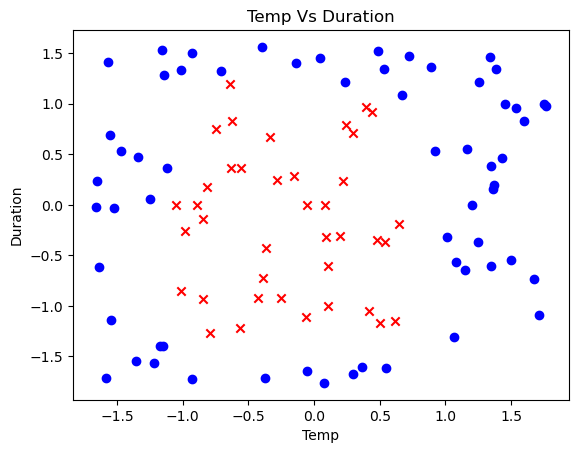

In [8]:
pos = y_train == 1
neg = y_train == 0

plt.scatter(x_train_scaled[pos, 0], x_train_scaled[pos, 1], marker = "x", color = "r")
plt.scatter(x_train_scaled[neg, 0], x_train_scaled[neg, 1], marker = "o", color = "b")
plt.xlabel("Temp")
plt.ylabel("Duration")
plt.title("Temp Vs Duration")
plt.show()

In [32]:
def my_dense(a_in, W, B):
    a_out = sigmoid(a_in @ W + B)
    return a_out

In [18]:
def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

In [19]:
def sequence(x, W1, B1, W2, B2):
    a1 = my_dense(x, W1, B1)
    a2 = my_dense(a1, W2, B2)
    return a2

In [20]:
W1 = np.array([[ 24.0, -24.0,   0.0,   0.0, -11.8304],
      [  0.0,   0.0,  24.0, -24.0,  -9.3844]])

b1 = np.array([25.8683, 22.8199, 32.4815, 28.8970, 15.3479])

W2 = np.array([[12.0], [12.0], [12.0], [12.0], [12.0]])

b2 = np.array([-54.0])

In [45]:
prediction = sequence(x_train_scaled, W1, b1, W2, b2)
prediction = (prediction >= 0.5).astype(int)
prediction = prediction.ravel()
prediction

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0])

In [63]:
accuracy = ((prediction == y_train).astype(int)).mean() * 100
accuracy

np.float64(100.0)

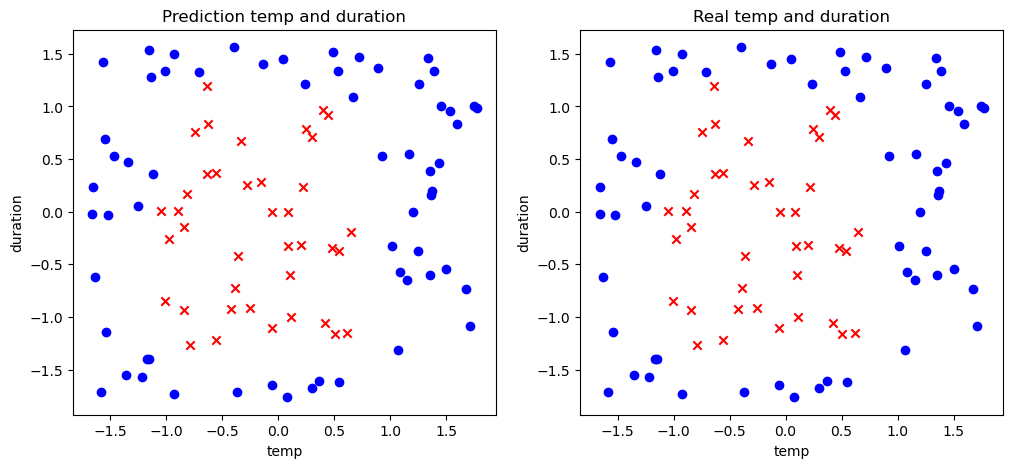

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

new_pos = prediction == 1
new_neg = prediction == 0


ax[0].scatter(x_train_scaled[new_pos, 0], x_train_scaled[new_pos, 1], marker = "x", color="r")
ax[0].scatter(x_train_scaled[new_neg, 0], x_train_scaled[new_neg, 1], marker = "o", color = "b")
ax[0].set_xlabel("temp")
ax[0].set_ylabel("duration")
ax[0].set_title("Prediction temp and duration")

ax[1].scatter(x_train_scaled[pos, 0], x_train_scaled[pos, 1], marker = "x", color="r")
ax[1].scatter(x_train_scaled[neg, 0], x_train_scaled[neg, 1], marker = "o", color = "b")
ax[1].set_xlabel("temp")
ax[1].set_ylabel("duration")
ax[1].set_title("Real temp and duration")


plt.show()

In [65]:
final_predict = np.array([[215, 13.0], [275, 14.5]])
final_predict_scaled = (final_predict - mean) / sigma
print((sequence(final_predict_scaled, W1, b1, W2, b2) >= 0.5).astype(int))

[[1]
 [0]]
